Logistic Regression
Accuracy: 0.7951219512195122
Precision: 0.7563025210084033
Recall: 0.8737864077669902

Naive Bayes
Accuracy: 0.8
Precision: 0.7540983606557377
Recall: 0.8932038834951457

Decision Tree
Accuracy: 0.9853658536585366
Precision: 1.0
Recall: 0.970873786407767


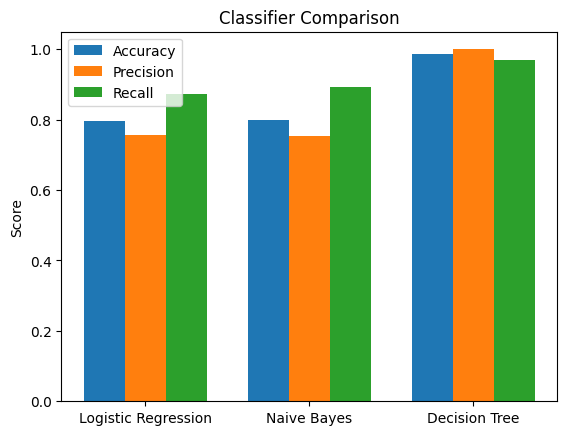

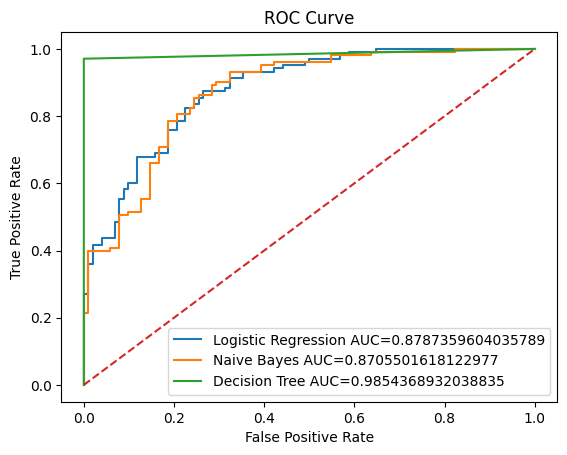


Prediction for New Patient
Logistic Regression: [1]
Naive Bayes: [0]
Decision Tree: [1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score

data = pd.read_csv("heart-2.csv")

X = data.drop("target",axis=1)
y = data["target"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

log_model = LogisticRegression()
nb_model = GaussianNB()
dt_model = DecisionTreeClassifier()

log_model.fit(X_train,y_train)
nb_model.fit(X_train,y_train)
dt_model.fit(X_train,y_train)

log_pred = log_model.predict(X_test)
nb_pred = nb_model.predict(X_test)
dt_pred = dt_model.predict(X_test)

log_acc = accuracy_score(y_test,log_pred)
nb_acc = accuracy_score(y_test,nb_pred)
dt_acc = accuracy_score(y_test,dt_pred)

log_pre = precision_score(y_test,log_pred)
nb_pre = precision_score(y_test,nb_pred)
dt_pre = precision_score(y_test,dt_pred)

log_rec = recall_score(y_test,log_pred)
nb_rec = recall_score(y_test,nb_pred)
dt_rec = recall_score(y_test,dt_pred)

print("Logistic Regression")
print("Accuracy:",log_acc)
print("Precision:",log_pre)
print("Recall:",log_rec)

print()

print("Naive Bayes")
print("Accuracy:",nb_acc)
print("Precision:",nb_pre)
print("Recall:",nb_rec)

print()

print("Decision Tree")
print("Accuracy:",dt_acc)
print("Precision:",dt_pre)
print("Recall:",dt_rec)

models = ["Logistic Regression","Naive Bayes","Decision Tree"]

accuracy = [log_acc,nb_acc,dt_acc]
precision = [log_pre,nb_pre,dt_pre]
recall = [log_rec,nb_rec,dt_rec]

x = np.arange(len(models))
width = 0.25

plt.bar(x-width,accuracy,width,label="Accuracy")
plt.bar(x,precision,width,label="Precision")
plt.bar(x+width,recall,width,label="Recall")

plt.xticks(x,models)
plt.ylabel("Score")
plt.title("Classifier Comparison")
plt.legend()

plt.show()

log_prob = log_model.predict_proba(X_test)[:,1]
nb_prob = nb_model.predict_proba(X_test)[:,1]
dt_prob = dt_model.predict_proba(X_test)[:,1]

log_fpr,log_tpr,_ = roc_curve(y_test,log_prob)
nb_fpr,nb_tpr,_ = roc_curve(y_test,nb_prob)
dt_fpr,dt_tpr,_ = roc_curve(y_test,dt_prob)

log_auc = roc_auc_score(y_test,log_prob)
nb_auc = roc_auc_score(y_test,nb_prob)
dt_auc = roc_auc_score(y_test,dt_prob)

plt.plot(log_fpr,log_tpr,label="Logistic Regression AUC="+str(log_auc))
plt.plot(nb_fpr,nb_tpr,label="Naive Bayes AUC="+str(nb_auc))
plt.plot(dt_fpr,dt_tpr,label="Decision Tree AUC="+str(dt_auc))

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

new_data = [[63,1,3,145,233,1,0,150,0,2.3,0,0,1]]

new_data_scaled = scaler.transform(new_data)

print()
print("Prediction for New Patient")

print("Logistic Regression:",log_model.predict(new_data_scaled))
print("Naive Bayes:",nb_model.predict(new_data_scaled))
print("Decision Tree:",dt_model.predict(new_data_scaled))


F1 Scores
Logistic Regression: 0.8108108108108109
Naive Bayes: 0.8177777777777778
Decision Tree: 0.9852216748768473


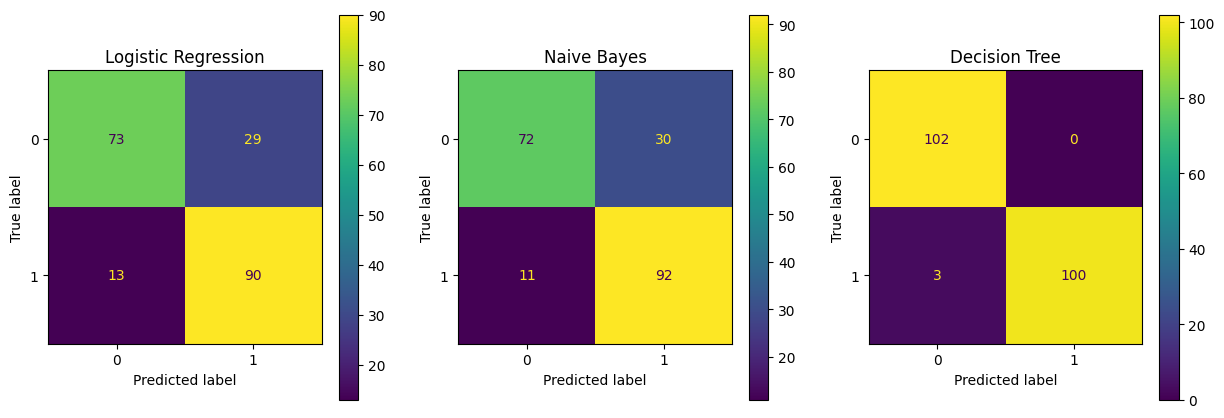

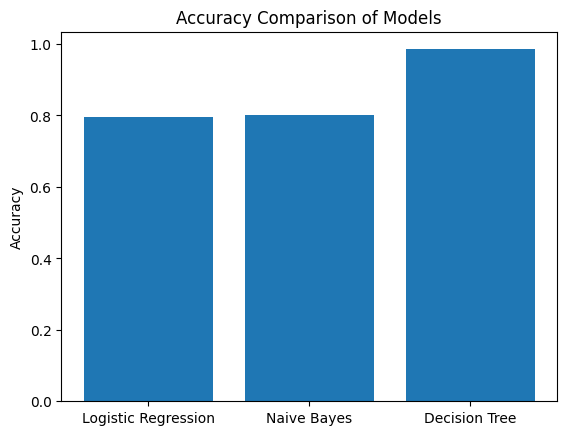

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.795122   0.756303  0.873786  0.810811
1          Naive Bayes  0.800000   0.754098  0.893204  0.817778
2        Decision Tree  0.985366   1.000000  0.970874  0.985222


In [ ]:
log_f1 = f1_score(y_test, log_pred)
nb_f1 = f1_score(y_test, nb_pred)
dt_f1 = f1_score(y_test, dt_pred)

print()
print("F1 Scores")

print("Logistic Regression:",log_f1)
print("Naive Bayes:",nb_f1)
print("Decision Tree:",dt_f1)

log_cm = confusion_matrix(y_test,log_pred)
nb_cm = confusion_matrix(y_test,nb_pred)
dt_cm = confusion_matrix(y_test,dt_pred)

fig, ax = plt.subplots(1,3, figsize=(15,5))

ConfusionMatrixDisplay(log_cm).plot(ax=ax[0])
ax[0].set_title("Logistic Regression")

ConfusionMatrixDisplay(nb_cm).plot(ax=ax[1])
ax[1].set_title("Naive Bayes")

ConfusionMatrixDisplay(dt_cm).plot(ax=ax[2])
ax[2].set_title("Decision Tree")

plt.show()

models = ["Logistic Regression","Naive Bayes","Decision Tree"]
accuracy = [log_acc, nb_acc, dt_acc]

plt.bar(models, accuracy)

plt.title("Accuracy Comparison of Models")
plt.ylabel("Accuracy")

plt.show()

results = pd.DataFrame({
    "Model": ["Logistic Regression","Naive Bayes","Decision Tree"],
    "Accuracy":[log_acc, nb_acc, dt_acc],
    "Precision":[log_pre, nb_pre, dt_pre],
    "Recall":[log_rec, nb_rec, dt_rec],
    "F1 Score":[log_f1, nb_f1, dt_f1]
})

print(results)